In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

#Importing Required Models
from sklearn.dummy import DummyClassifier #To set a baseline for models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#Importing Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score, f1_score, r2_score, precision_score, recall_score)

#Other required imports
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
data.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [4]:
data = data.drop(columns=['customerID', 'TotalCharges'])

In [5]:
def check_data(data):
    # Basic Info
    print(f"Dataset Shape: {data.shape[0]} rows, {data.shape[1]} columns")
    print(f"Total Duplicate Rows: {data.duplicated().sum()}")
    print('-' * 50)

    #Creating Column Summary DataFrame
    return pd.DataFrame({
        'Data Type': data.dtypes,
        'Null Values': data.isnull().sum(),
        'Unique Values': data.nunique(),
        'Duplicate Values': data.duplicated().sum()
    })

# Calling the function
summary_data = check_data(data)
summary_data

Dataset Shape: 7043 rows, 19 columns
Total Duplicate Rows: 27
--------------------------------------------------


,Data Type,Null Values,Unique Values,Duplicate Values
gender,str,0,2,27
SeniorCitizen,int64,0,2,27
Partner,str,0,2,27
Dependents,str,0,2,27
tenure,int64,0,73,27
PhoneService,str,0,2,27
MultipleLines,str,0,3,27
InternetService,str,0,3,27
OnlineSecurity,str,0,3,27
OnlineBackup,str,0,3,27


In [6]:
data.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No


In [7]:
def check_all_categorical_counts(data):
    cat_cols = data.select_dtypes(include=['object', 'category']).columns
    
    for col in cat_cols:
        print(data[col].value_counts())
        print("-" * 30 + "\n")

check_all_categorical_counts(data)

gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------------------

Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------------------

Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------------------

PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------------------------

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------------------------------

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------------------------------

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------------------------------

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
------------------------------

DeviceProtection
No               

In [8]:
## 1 for Male, 0 for Female
data['gender'] = data['gender'].apply(lambda x: 1 if x == 'Male' else 0)

# 1 for Yes, 0 for No
data['Partner'] = data['Partner'].apply(lambda x: 1 if x == 'Yes' else 0)
data['Dependents'] = data['Dependents'].apply(lambda x: 1 if x == 'Yes' else 0)
data['PhoneService'] = data['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)
data['PaperlessBilling'] = data['PaperlessBilling'].apply(lambda x: 1 if x == 'Yes' else 0)
data['Churn'] = data['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

data['MultipleLines'] = data['MultipleLines'].map({'No phone service' : 0, 'No' : 1, 'Yes' : 2})

data['InternetService'] = data['InternetService'].map({'No' : 0, 'DSL' : 1, 'Fiber optic' : 2})

data['PaymentMethod'] = data['PaymentMethod'].map({'Electronic check' : 0, 'Mailed check' : 1, 'Bank transfer (automatic)' : 2, 'Credit card (automatic)' : 3})

data['StreamingTV'] = data['StreamingTV'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

data['StreamingMovies'] = data['StreamingMovies'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

data['TechSupport'] = data['TechSupport'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

data['DeviceProtection'] = data['DeviceProtection'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

data['OnlineBackup'] = data['OnlineBackup'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

data['OnlineSecurity'] = data['OnlineSecurity'].map({'No internet service' : 0, 'No' : 1, 'Yes' : 2})

In [9]:
le = LabelEncoder()
data['Contract'] = le.fit_transform(data['Contract'])

In [10]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,0,1,1,2,1,1,1,1,0,1,0,29.85,0
1,1,0,0,0,34,1,1,1,2,1,2,1,1,1,1,0,1,56.95,0
2,1,0,0,0,2,1,1,1,2,2,1,1,1,1,0,1,1,53.85,1
3,1,0,0,0,45,0,0,1,2,1,2,2,1,1,1,0,2,42.30,0
4,0,0,0,0,2,1,1,2,1,1,1,1,1,1,0,1,0,70.70,1


In [11]:
x = data.drop(columns=['Churn'])
y = data['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [12]:
scaler = StandardScaler()
cols_to_scale = ['tenure', 'MonthlyCharges']

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

In [13]:
x_train_scaled[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test_scaled[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

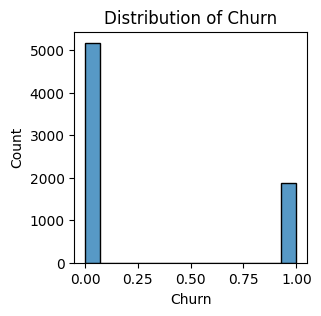

In [14]:
# Visualize the distribution of Churn:
plt.figure(figsize=(3, 3))
sns.histplot(data['Churn'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  
 17  Monthl

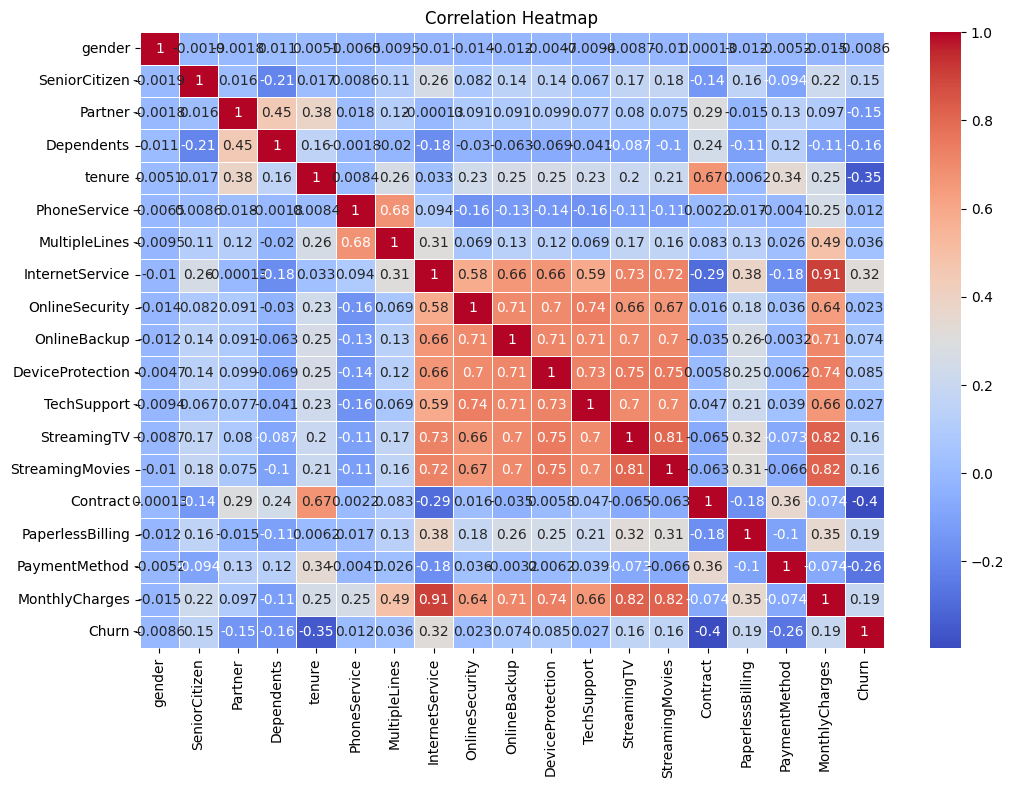

In [16]:
# Visualize a correlation heatmap:
correlation_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [17]:
data = data.drop(columns=['InternetService', 'StreamingTV', 'StreamingMovies'])

### Even if columns like InternetService, StreamingTV and StreamingMovies have a high correaltion score of more than 0.80, I haven't removed them because they still hold a good information about churn. As per the telecom domain, they are often significant drivers of churn.

In [18]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,0,1,2,1,1,0,1,0,29.85,0
1,1,0,0,0,34,1,1,2,1,2,1,1,0,1,56.95,0
2,1,0,0,0,2,1,1,2,2,1,1,0,1,1,53.85,1
3,1,0,0,0,45,0,0,2,1,2,2,1,0,2,42.30,0
4,0,0,0,0,2,1,1,1,1,1,1,0,1,0,70.70,1


#### Dummy Classifier Model

In [19]:
dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(x_train_scaled, y_train)

dummy_y_pred = dummy_model.predict(x_test_scaled)

In [20]:
# Calculating Metrics
print(f'Accuracy: {accuracy_score(y_test, dummy_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, dummy_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, dummy_y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, dummy_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, dummy_y_pred):.2f}')

Accuracy: 0.73
Precision: 0.00
Recall: 0.00
R2 Score: -0.36
F1 Score: 0.00


#### Logistic Regression Model

In [21]:
log_model = LogisticRegression(random_state=42)
log_model.fit(x_train_scaled, y_train)

log_y_pred = log_model.predict(x_test_scaled)

In [22]:
# Calculating Metrics
print(f'Accuracy: {accuracy_score(y_test, log_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, log_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, log_y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, log_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, log_y_pred):.2f}')

Accuracy: 0.80
Precision: 0.65
Recall: 0.54
R2 Score: -0.01
F1 Score: 0.59


#### Decision Tree Model

In [23]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train_scaled, y_train)

dt_y_pred = dt_model.predict(x_test_scaled)

In [24]:
# Calculating Metrics
print(f'Accuracy: {accuracy_score(y_test, dt_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, dt_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, dt_y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, dt_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, dt_y_pred):.2f}')

Accuracy: 0.73
Precision: 0.50
Recall: 0.49
R2 Score: -0.37
F1 Score: 0.49


#### Random Forest Classifier Model

In [25]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_scaled, y_train)

rf_y_pred = rf_model.predict(x_test_scaled)

In [26]:
# Calculating Metrics
print(f'Accuracy: {accuracy_score(y_test, rf_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, rf_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, rf_y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, rf_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, rf_y_pred):.2f}')

Accuracy: 0.79
Precision: 0.63
Recall: 0.49
R2 Score: -0.09
F1 Score: 0.55


In [27]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train_scaled, y_train)

gb_y_pred = gb_model.predict(x_test_scaled)

In [28]:
# Calculating Metrics
print(f'Accuracy: {accuracy_score(y_test, gb_y_pred):.2f}')
print(f'Precision: {precision_score(y_test, gb_y_pred):.2f}')
print(f'Recall: {recall_score(y_test, gb_y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, gb_y_pred):.2f}')
print(f'F1 Score: {f1_score(y_test, gb_y_pred):.2f}')

Accuracy: 0.80
Precision: 0.66
Recall: 0.50
R2 Score: -0.03
F1 Score: 0.57


In [29]:
lr_param_grid ={
    'C' : [0.001, 0.01, 0.1, 1, 10],
    'class_weight' : [None, 'balanced'],
    'solver' : ['liblinear', 'lbfgs']}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1)

print('Tuning Hyperparameters... This might take few seconds.')
grid_search.fit(x_train_scaled, y_train)

Tuning Hyperparameters... This might take few seconds.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [30]:
best_model = grid_search.best_estimator_
print(f'Best Parameters Found: {grid_search.best_params_}')

Best Parameters Found: {'C': 0.1, 'class_weight': 'balanced', 'solver': 'liblinear'}


In [31]:
tuned_y_pred = best_model.predict(x_test_scaled)

tuned_y_pred_proba = best_model.predict_proba(x_test_scaled)[:,1]

print('----------------- Classification Report -------------')
print(classification_report(y_test, tuned_y_pred))

auc_score = roc_auc_score(y_test, tuned_y_pred_proba)
print(f'ROC-AUC Score: {auc_score:.3f}\n')

----------------- Classification Report -------------
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

ROC-AUC Score: 0.842



----------------- Confusion Matrix -------------


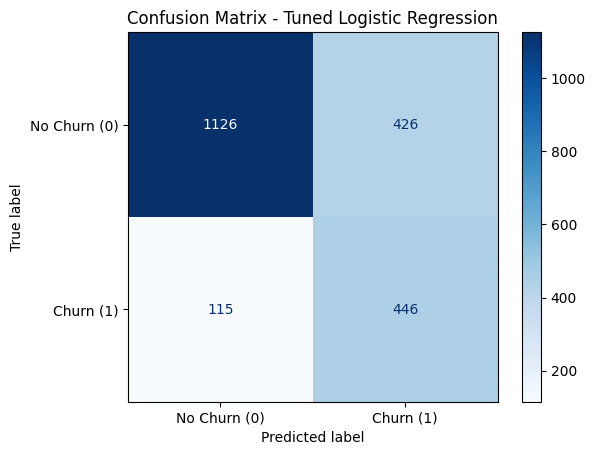

In [32]:
print(('----------------- Confusion Matrix -------------'))
ConfusionMatrixDisplay.from_estimator(
    best_model, x_test_scaled, y_test, cmap='Blues', display_labels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()

Tuning Random Forest... This may take a minute.


Best Random Forest Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1552
           1       0.55      0.70      0.61       561

    accuracy                           0.77      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.79      0.77      0.78      2113

ROC-AUC Score: 0.835902



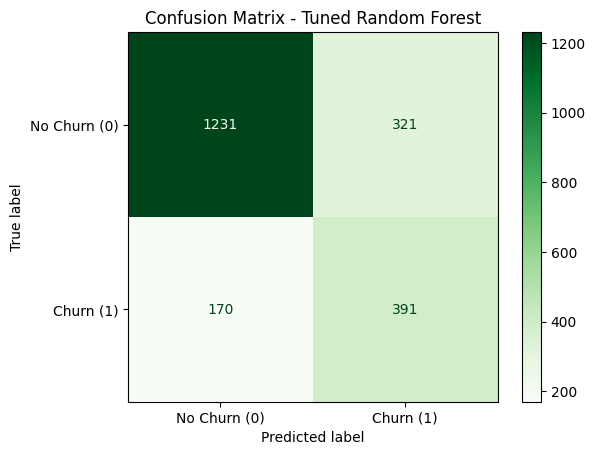

In [33]:
rf_param_grid = {
    'n_estimators' : [100,200],
    'max_depth' : [10,20,None],
    'class_weight' : ['balanced', 'balanced_subsample'],
    'min_samples_split' : [2,5]}

print('Tuning Random Forest... This may take a minute.')
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1)

rf_grid_search.fit(x_train_scaled, y_train)

best_rf_model = rf_grid_search.best_estimator_
print(f'Best Random Forest Parameters: {rf_grid_search.best_params_}\n')

rf_y_pred = best_rf_model.predict(x_test_scaled)
rf_y_pred_proba = best_rf_model.predict_proba(x_test_scaled)[:,1]

print('--- Random Forest Classification Report ---')
print(classification_report(y_test, rf_y_pred))
print(f'ROC-AUC Score: {roc_auc_score(y_test, rf_y_pred_proba):3f}\n')

ConfusionMatrixDisplay.from_estimator(best_rf_model, x_test_scaled, y_test, cmap='Greens', display_labels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

Tuning Gradient Boosting... This may take a couple of minutes.


Best GB Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}

--- Gradient Boosting Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1552
           1       0.65      0.50      0.57       561

    accuracy                           0.80      2113
   macro avg       0.74      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113

ROC-AUC Score: 0.837



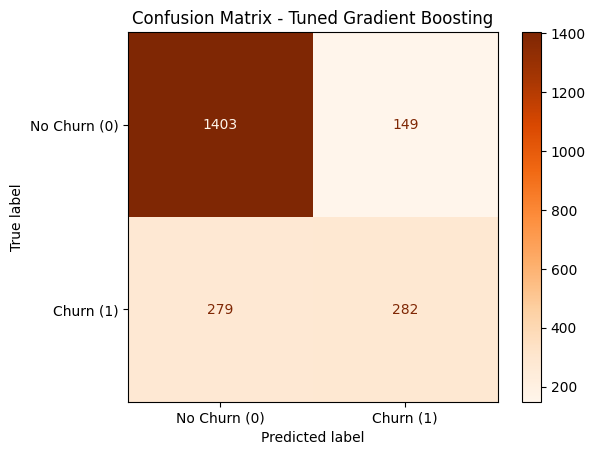

In [34]:
# 1. Define the parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2], # How much each tree contributes
    'max_depth': [3, 5, 7]             # Depth of individual trees
}

# 2. Initialize and fit GridSearchCV
print("Tuning Gradient Boosting... This may take a couple of minutes.")
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring='f1', 
    cv=5, 
    n_jobs=-1
)
gb_grid_search.fit(x_train_scaled, y_train)

# 3. Extract best model and evaluate
best_gb_model = gb_grid_search.best_estimator_
print(f"Best GB Parameters: {gb_grid_search.best_params_}\n")

gb_y_pred = best_gb_model.predict(x_test_scaled)
gb_y_pred_proba = best_gb_model.predict_proba(x_test_scaled)[:, 1]

print("--- Gradient Boosting Classification Report ---")
print(classification_report(y_test, gb_y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, gb_y_pred_proba):.3f}\n")

# 4. Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_gb_model, x_test_scaled, y_test, cmap='Oranges', display_labels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Tuned Gradient Boosting')
plt.show()

Tuning XGBoost... This might take a minute.


Best XGB Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 3}

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.70      0.79      1552
           1       0.50      0.82      0.62       561

    accuracy                           0.73      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.73      0.75      2113

ROC-AUC Score: 0.842



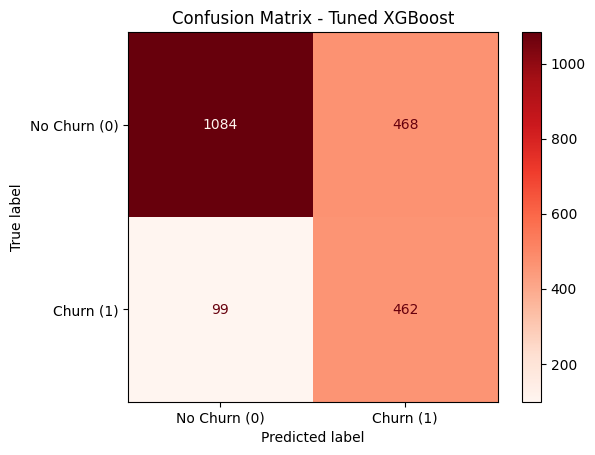

In [35]:
# 1. Defining the parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, 3, 5]
}

# 2. Initialize and fit GridSearchCV
print("Tuning XGBoost... This might take a minute.")
xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    scoring='f1', 
    cv=5, 
    n_jobs=-1
)
xgb_grid_search.fit(x_train_scaled, y_train)

# 3. Extract best model and evaluate
best_xgb_model = xgb_grid_search.best_estimator_
print(f"Best XGB Parameters: {xgb_grid_search.best_params_}\n")

xgb_y_pred = best_xgb_model.predict(x_test_scaled)
xgb_y_pred_proba = best_xgb_model.predict_proba(x_test_scaled)[:, 1]

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_y_pred_proba):.3f}\n")

# 4. Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_xgb_model, x_test_scaled, y_test, cmap='Reds', display_labels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

Tuning KNN... This should be fast.


Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}

--- KNN Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1552
           1       0.59      0.53      0.56       561

    accuracy                           0.78      2113
   macro avg       0.71      0.70      0.70      2113
weighted avg       0.77      0.78      0.77      2113

ROC-AUC Score: 0.816



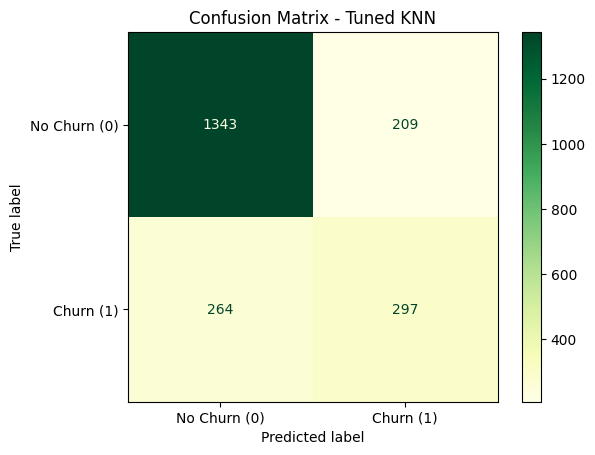

In [36]:
# 1. Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],       # Number of neighbors to consider
    'weights': ['uniform', 'distance'],    # How to weight the neighbors
    'metric': ['euclidean', 'manhattan']   # How to calculate distance
}

# 2. Initialize and fit GridSearchCV
print("Tuning KNN... This should be fast.")
knn_grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1', 
    cv=5, 
    n_jobs=-1
)
knn_grid_search.fit(x_train_scaled, y_train)

# 3. Extract best model and evaluate
best_knn_model = knn_grid_search.best_estimator_
print(f"Best KNN Parameters: {knn_grid_search.best_params_}\n")

knn_y_pred = best_knn_model.predict(x_test_scaled)
knn_y_pred_proba = best_knn_model.predict_proba(x_test_scaled)[:, 1]

print("--- KNN Classification Report ---")
print(classification_report(y_test, knn_y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, knn_y_pred_proba):.3f}\n")

# 4. Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_knn_model, x_test_scaled, y_test, cmap='YlGn', display_labels=['No Churn (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Tuned KNN')
plt.show()

In [37]:
# 1. Consolidate Metrics into a DataFrame
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Recall (Class 1)': [
        recall_score(y_test, tuned_y_pred),
        recall_score(y_test, rf_y_pred),
        recall_score(y_test, gb_y_pred),
        recall_score(y_test, xgb_y_pred)
    ],
    'F1-Score (Class 1)': [
        f1_score(y_test, tuned_y_pred),
        f1_score(y_test, rf_y_pred),
        f1_score(y_test, gb_y_pred),
        f1_score(y_test, xgb_y_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, tuned_y_pred_proba),
        roc_auc_score(y_test, rf_y_pred_proba),
        roc_auc_score(y_test, gb_y_pred_proba),
        roc_auc_score(y_test, xgb_y_pred_proba)
    ]
}

results_df = pd.DataFrame(metrics_data).sort_values(by='Recall (Class 1)', ascending=False)
display(results_df.style.background_gradient(cmap='Blues'))

,Model,Recall (Class 1),F1-Score (Class 1),ROC-AUC
3,XGBoost,0.823529,0.619718,0.842266
0,Logistic Regression,0.795009,0.622470,0.841914
1,Random Forest,0.696970,0.614297,0.835902
2,Gradient Boosting,0.502674,0.568548,0.837072


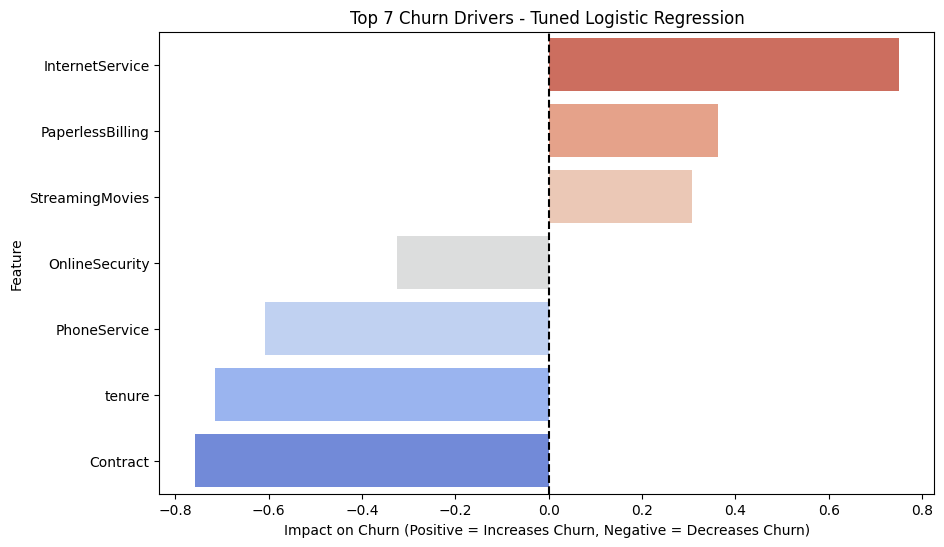

In [38]:
# Extracting feature names and coefficients from the tuned Logistic Regression model
feature_names = x_train_scaled.columns
coefficients = best_model.coef_[0]

# Create a DataFrame for the features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': abs(coefficients)
})

# Sort by the most impactful features (absolute value) and take the top 7
top_features = importance_df.sort_values(by='Absolute_Importance', ascending=False).head(7)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features.sort_values(by='Coefficient', ascending=False), 
    x='Coefficient', 
    y='Feature', 
    palette='coolwarm_r'
)
plt.title('Top 7 Churn Drivers - Tuned Logistic Regression')
plt.xlabel('Impact on Churn (Positive = Increases Churn, Negative = Decreases Churn)')
plt.ylabel('Feature')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

## Final Conclusion and Business Recommendations

### Model Selection
After testing multiple algorithms (Logistic Regression, Random Forest, Gradient Boosting, and XGBoost) and tuning their hyperparameters to handle class imbalance, **Logistic Regression** was selected as the Champion Model. 
* **Recall (Churn): 80%** (It successfully catches 8 out of 10 customers who are going to leave).
* **ROC-AUC: 84.2%** (It has strong discriminatory power between classes).

### Key Drivers of Churn
Based on the feature importance analysis, the primary factors influencing customer churn are:
1. **Contract Type:** Customers on Month-to-Month contracts are significantly more likely to churn compared to those on 1-year or 2-year contracts.
2. **Tenure:** Shorter tenure strongly correlates with higher churn. Customers are most vulnerable in their early months with the company.
3. **Monthly Charges:** Higher monthly bills push customers toward churning.
4. **Internet Service Type:** (If Fiber Optic appears high on your chart, mention it here).

### Actionable Business Recommendations
1. **Incentivize Long-Term Contracts:** Since Month-to-Month contracts are the highest risk factor, the marketing team should design targeted campaigns offering a slight discount or a free service add-on (like Tech Support) to customers who agree to upgrade to a 1-year contract.
2. **Early Retention Programs:** Because low tenure drives churn, customer success teams should implement a proactive check-in sequence during a customer's first 3 to 6 months to ensure satisfaction and smooth onboarding.
3. **Price Sensitivity Adjustments:** For customers flagged by the model as "High Risk" who also have high `MonthlyCharges`, trigger an automated promotional discount or suggest a right-sized plan that better fits their actual usage to prevent them from seeking cheaper competitors.

## Deploying This Model

This notebook is for analysis and model comparison. For a production-ready, leakage-safe version that bundles preprocessing + scaling + the tuned Logistic Regression model into a single artifact for real-time inference, see:

- `src/preprocessing.py` — the single source of truth for feature engineering
- `src/train_model.py` — trains and saves `models/churn_pipeline.joblib`
- `app.py` — a Streamlit app that loads the joblib file and scores a customer instantly

Run `python src/train_model.py` from the repo root to reproduce the deployable model.